# La separación, paso a paso

**Objetivo.** Presentar con cuidado la jerarquía
$U^{\text{single}} \le U^s_{NO} \le U^s_{O} \le U^D \le U^D_A \le U^{\max}$
y, sobre todo, el eslabón nuevo $U^D \le U^D_A$: el valor de contar.

**Cómo leerlo.** No empezamos por la tabla. Subimos en capas: el mecanismo en una
instancia, por qué la cadena vale siempre, la jerarquía vista en instancias
concretas, el promedio como cascada, y el crecimiento del beneficio con la escala,
mostrando su distribución y no solo la media. La tabla agregada va al cierre.

**Procedencia.** Todo se regenera aquí desde `hierarchy_experiment.py` (código
corregido) y los CSV por instancia en `results/hierarchy/`. No hay números
escritos a mano.


In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import augmented
ROOT = os.path.dirname(os.path.dirname(os.path.abspath(augmented.__file__)))

from augmented.core import mask_from_indices
from augmented.bayesian import bayesian_update_by_counting
from augmented.hierarchy_experiment import hierarchy_for_instance, CHAIN

print('repo root:', ROOT)
print('cadena:', ' <= '.join(CHAIN))

repo root: /Users/hectorbecerrilvillamil/Desktop/PooledTesting/pooled-testing-dynamic
cadena: U_single <= U_s_NO <= U_s_O <= U_D <= U_D_A <= U_max


## Capa 1a — El mecanismo: una deducción que el binario NO puede hacer

El ejemplo tiene que separar de verdad el conteo del binario; si no, no prueba
nada. Tres personas, dos tests: $\{0,1,2\}=1$ y $\{1,2\}=1$. El conteo dice que
hay exactamente un infectado en todo el grupo y exactamente uno entre $\{1,2\}$;
ese único infectado vive en $\{1,2\}$, así que **0 queda sano con certeza**.

Un planificador binario ve los mismos dos pools como positivo y positivo, y de ahí
no puede concluir nada sobre 0: $\{0,1,2\}$ positivo solo dice "hay alguien", que ya
lo implica $\{1,2\}$ positivo. La aritmética del conteo es la que libera a 0. Y
deducir a alguien sano es justo lo que luego se puede cosechar como utilidad, así
que esta deducción es la semilla del bienestar extra.

In [2]:
p = [0.3, 0.3, 0.3]
historia = ((mask_from_indices([0, 1, 2]), 1), (mask_from_indices([1, 2]), 1))
post = bayesian_update_by_counting(p, historia, 3)
print('prior  P(infectado) :', p)
print('tests              : {0,1,2}=1 , {1,2}=1')
print('posterior augmented :', [round(x, 3) for x in post])
print()
print('x0 = 0.0  -> deducido SANO con certeza (cosechable).')
print('Binario ve {0,1,2}=+ , {1,2}=+ y NO puede concluir el estado de 0.')

prior  P(infectado) : [0.3, 0.3, 0.3]
tests              : {0,1,2}=1 , {1,2}=1
posterior augmented : [0.0, 0.5, 0.5]

x0 = 0.0  -> deducido SANO con certeza (cosechable).
Binario ve {0,1,2}=+ , {1,2}=+ y NO puede concluir el estado de 0.


## Capa 1b — Por qué la cadena vale para TODA instancia

Conviene aclarar antes de las figuras: la cadena no es un patrón que el código
descubre, es una desigualdad que vale por construcción, y lo empírico es el
**tamaño** de cada brecha.

Cada eslabón añade un poder y nunca puede empeorar el óptimo. Testear de a uno es
un caso particular de planes estáticos sin solapar, que son un caso particular de
estáticos con solape. Un plan estático es un plan dinámico que ignora la historia,
así que el óptimo dinámico no puede ser peor. El test augmented refina al binario
(el binario es el indicador $\mathbf{1}[r>0]$ del conteo), de modo que cualquier
política binaria es ejecutable con conteo, y por eso $U^D \le U^D_A$. Y
$U^{\max} = \sum_i u_i q_i$ es la cota de información total: lo que se obtendría
conociendo el estado de todos. Lo único que medimos abajo es cuánto se separan
estos niveles, que sí depende de la instancia.

## Capa 1c — La jerarquía en instancias concretas: mediana y testigo

Mostramos la escalera en dos instancias, no en una, para no confundir el mecanismo
con la evidencia. La de la izquierda tiene la brecha mediana del conteo; la de la
derecha es una instancia testigo, elegida a propósito por su brecha alta para que el
eslabón $U^D \to U^D_A$ se vea. La diferencia entre ambas ya adelanta que la
ventaja del conteo no es uniforme.

In [3]:
rng = np.random.default_rng(7)
N, B, G = 5, 3, 5
muestras = []
for _ in range(60):
    p = rng.uniform(0.0, 1.0, size=N).tolist()
    u = rng.choice([1.0, 2.0, 3.0], size=N).tolist()
    h = hierarchy_for_instance(p, u, B, G)
    muestras.append((h['U_D_A'] - h['U_D'], p, u, h))
muestras.sort(key=lambda x: x[0])
mediana = muestras[len(muestras) // 2]
testigo = muestras[-1]
print(f'mediana de la brecha (de 60): {mediana[0]:.4f}')
print(f'testigo (brecha maxima)      : {testigo[0]:.4f}')

mediana de la brecha (de 60): 0.1456
testigo (brecha maxima)      : 0.5402


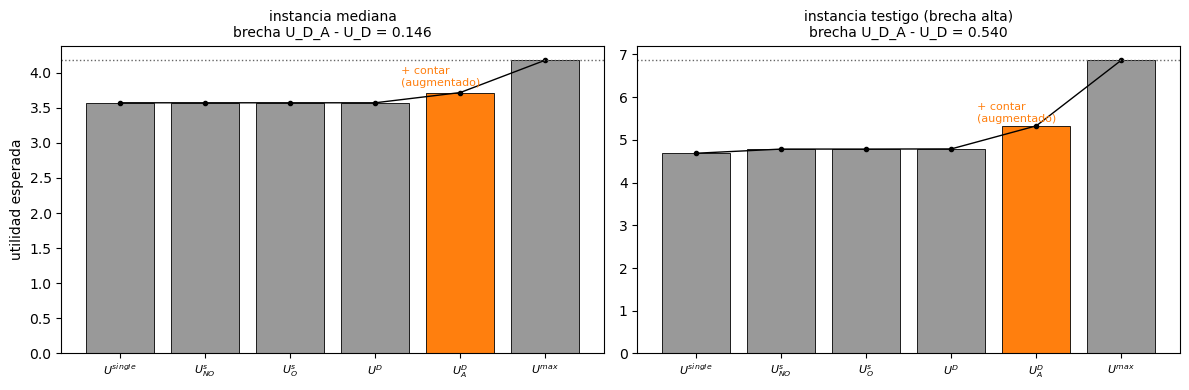

In [4]:
etiquetas = [r'$U^{single}$', r'$U^s_{NO}$', r'$U^s_O$',
             r'$U^D$', r'$U^D_A$', r'$U^{max}$']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (gap, p, u, h), titulo in [
        (axes[0], mediana, 'instancia mediana'),
        (axes[1], testigo, 'instancia testigo (brecha alta)')]:
    vals = [h[k] for k in CHAIN]
    colores = ['0.6'] * len(CHAIN); colores[CHAIN.index('U_D_A')] = 'tab:orange'
    ax.bar(range(len(vals)), vals, color=colores, edgecolor='k', linewidth=0.6)
    ax.plot(range(len(vals)), vals, 'k.-', lw=1)
    ax.axhline(h['U_max'], ls=':', color='0.4', lw=1)  # Umax es cota, no peldano
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(etiquetas, fontsize=8)
    ax.set_title(f'{titulo}\nbrecha U_D_A - U_D = {gap:.3f}', fontsize=10)
    ax.annotate('+ contar\n(augmentado)', xy=(CHAIN.index('U_D_A'), h['U_D_A']),
                xytext=(CHAIN.index('U_D_A') - 0.7, h['U_D_A'] + 0.1),
                color='tab:orange', fontsize=8)
axes[0].set_ylabel('utilidad esperada')
plt.tight_layout(); plt.show()

## Capa 2 — ¿Qué tan seguido es estricto cada eslabón?

Antes de promediar, la objeción honesta: muchas desigualdades son igualdades en una
fracción grande de instancias. La tabla siguiente cuenta, por eslabón, en cuántas
instancias hay separación estricta. En particular, en $N=3$ el conteo no aporta nada
en más de la mitad de los casos; el promedio positivo lo cargan unas pocas
instancias.

In [5]:
df = pd.concat([
    pd.read_csv(os.path.join(ROOT, 'results/hierarchy/hierarchy_small.csv')),
    pd.read_csv(os.path.join(ROOT, 'results/hierarchy/hierarchy_n7.csv')),
], ignore_index=True)
df['benefit_pct'] = (df['U_D_A'] - df['U_D']) / df['U_D'] * 100.0

eslabones = list(zip(CHAIN[:-1], CHAIN[1:]))
filas = []
for N in sorted(df['N'].unique()):
    d = df[df['N'] == N]; n = len(d)
    fila = {'N': N, 'n_inst': n}
    for a, b in eslabones:
        estrictos = ((d[b] - d[a]) > 1e-9).sum()
        fila[f'{a}<{b}'] = f'{estrictos}/{n}'
    filas.append(fila)
print(pd.DataFrame(filas).to_string(index=False))

 N  n_inst U_single<U_s_NO U_s_NO<U_s_O U_s_O<U_D U_D<U_D_A U_D_A<U_max
 3     200          41/200       29/200    63/200    93/200     200/200
 5     200          86/200       82/200   132/200   196/200     200/200
 7      40           22/40        24/40     34/40     40/40       40/40


## Capa 3 — El promedio como cascada (con el techo como cota)

Cada barra es cuánto bienestar agrega cada capacidad respecto a la anterior. La
primera es el testeo individual; cada siguiente suma un poder: agrupar muestras,
solapar pools, **adaptar** (ser dinámico, es decir elegir cada test según la
historia, frente a fijar todo de antemano) y **contar** (usar el test augmentado de
conteo en vez del binario). Dos precisiones para no confundir: "adaptar" es
estático→dinámico, no es el greedy; y esta figura compara óptimos exactos (DP), no
heurísticas. La barra de "contar" es exactamente el eslabón nuevo $U^D_A - U^D$. El
techo $U^{\max}$ no es otra tecnología de testeo sino una cota superior, así que va
como línea punteada y la cascada termina en $U^D_A$; el hueco hasta la línea es el
margen que ninguna política, ni la augmented óptima, puede recuperar.

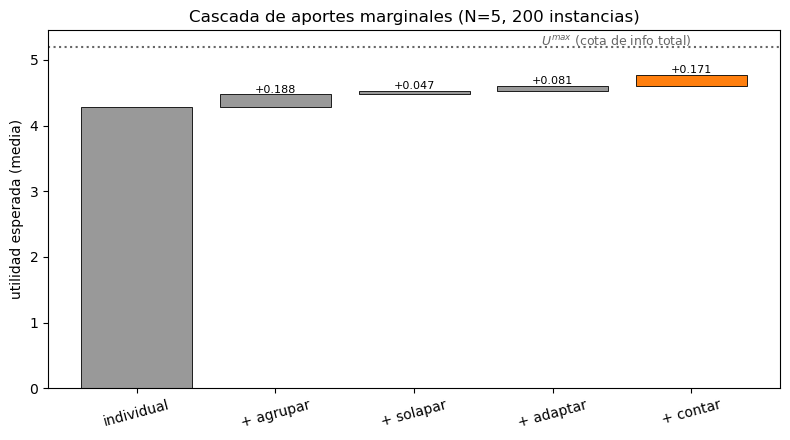

Aporte medio de CONTAR (U_D_A - U_D) = 0.1707


In [6]:
N_show = 5
m = df[df['N'] == N_show][CHAIN].mean()
niveles = CHAIN[:-1]  # la cascada llega hasta U_D_A; U_max es cota
incs = [m[niveles[0]]] + [m[niveles[i]] - m[niveles[i-1]]
                          for i in range(1, len(niveles))]
etq = ['individual', '+ agrupar', '+ solapar', '+ adaptar', '+ contar']
colores = ['0.6'] * len(niveles); colores[-1] = 'tab:orange'

fig, ax = plt.subplots(figsize=(8, 4.5))
base = 0.0
for i, inc in enumerate(incs):
    ax.bar(i, inc, bottom=base, color=colores[i], edgecolor='k', linewidth=0.6)
    if i > 0:
        ax.text(i, base + inc + 0.03, f'+{inc:.3f}', ha='center', fontsize=8)
    base += inc
ax.axhline(m['U_max'], ls=':', color='0.4', lw=1.5)
ax.text(len(niveles) - 1, m['U_max'] + 0.03, r'$U^{max}$ (cota de info total)',
        ha='right', color='0.4', fontsize=9)
ax.set_xticks(range(len(niveles))); ax.set_xticklabels(etq, rotation=15)
ax.set_ylabel('utilidad esperada (media)')
ax.set_title(f'Cascada de aportes marginales (N={N_show}, '
             f'{int((df.N==N_show).sum())} instancias)')
plt.tight_layout(); plt.show()
print(f'Aporte medio de CONTAR (U_D_A - U_D) = {incs[-1]:.4f}')

## Capa 4 — El beneficio del conteo: distribución, no solo media

La historia central, pero contada con la distribución completa. Para cada $N$,
el beneficio relativo $(U^D_A - U^D)/U^D$ por instancia, como caja y puntos. La
media sube con la escala, pero la caja revela lo que la media esconde: en $N=3$ la
mediana es cero (el conteo no aporta en la mayoría) y la cola es la que mueve el
promedio; en $N=5$ y $N=7$ la masa ya es positiva y dispersa.

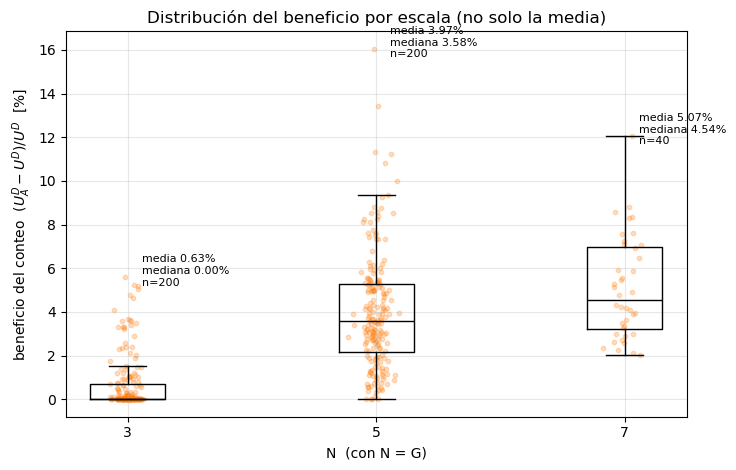

In [7]:
Ns = sorted(df['N'].unique())
datos = [df[df['N'] == N]['benefit_pct'].values for N in Ns]
jr = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.boxplot(datos, positions=Ns, widths=0.6, showfliers=False,
           medianprops=dict(color='k'))
for N, y in zip(Ns, datos):
    x = jr.normal(N, 0.06, size=len(y))
    ax.scatter(x, y, alpha=0.25, s=10, color='tab:orange')
    ax.annotate(f'media {y.mean():.2f}%\nmediana {np.median(y):.2f}%\nn={len(y)}',
                (N, y.max()), textcoords='offset points', xytext=(10, -6),
                fontsize=8)
ax.set_xlabel('N  (con N = G)'); ax.set_xticks(Ns)
ax.set_ylabel(r'beneficio del conteo  $(U^D_A-U^D)/U^D$  [%]')
ax.set_title('Distribución del beneficio por escala (no solo la media)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura honesta del crecimiento.** La media sube de $N=3$ a $N=7$, lo cual
es consistente con el mecanismo (el conteo paga vía mejores posteriores sobre un
horizonte más largo). Pero es evidencia, no prueba: son tres puntos, $N$, $B$ y $G$
se mueven a la vez (no aísla cuál causa el crecimiento), y $N=7$ tiene solo 40
instancias. La tendencia es sugerente; el experimento limpio que separe el efecto
de $N$, del horizonte $B$ y del tamaño de pool $G=N$ queda pendiente.

## Capa 5 — La tabla, ya entendida, y las salvedades

Recién ahora la tabla agregada. Se reportan dos formas del beneficio para que no
haya ambigüedad: la media de los cocientes por instancia, $E[(U^D_A-U^D)/U^D]$, que
es la que cuenta la curva de arriba, y el cociente de las medias,
$(\,\overline{U^D_A}-\overline{U^D}\,)/\overline{U^D}$, que no es lo mismo.

In [8]:
g = df.groupby(['N', 'B', 'G'])
tabla = g[CHAIN].mean()
tabla['E[gap/U_D]_%'] = g['benefit_pct'].mean()
tabla['gapMean/U_Dmean_%'] = (g['U_D_A'].mean() - g['U_D'].mean()) / g['U_D'].mean() * 100
tabla['n_inst'] = g.size()
print(tabla.round(4).to_string())

       U_single  U_s_NO   U_s_O     U_D   U_D_A   U_max  E[gap/U_D]_%  gapMean/U_Dmean_%  n_inst
N B G                                                                                           
3 2 3    2.5716  2.6434  2.6587  2.6860  2.7040  2.9920        0.6284             0.6710     200
5 3 5    4.2841  4.4725  4.5194  4.6000  4.7707  5.1894        3.9693             3.7115     200
7 3 7    4.9081  5.2486  5.3354  5.4542  5.7174  6.8057        5.0718             4.8266      40


**Montaje experimental (sin esconder nada).** Priors $p_i \sim U(0,1)$ y
utilidades $u_i \sim \text{Uniforme}\{1,2,3\}$, instancias independientes. La cadena
$U^{\text{single}} \le \dots \le U^{\max}$ se cumple en todas (cero violaciones).
Configuraciones en la diagonal $N=G$, con $B$ creciendo modestamente. $N=3$ y $N=5$
usan 200 instancias; $N=7$ solo 40, porque el DP exacto $U^D_A$ a $N=7$ es caro
(ramifica en $|t|+1$ resultados), de ahí su caja más rala. Relanzar $N=7$ con más
instancias está listo en el código.

## Preguntas para Francisco

Tres ganchos. ¿El valor por paso bajo conteo es submodular adaptativo? De serlo, el
greedy heredaría una garantía $1 - 1/e$. ¿Cómo cambia la separación cuando el conteo
se observa con ruido, como el cycle threshold real de la qPCR? ¿En qué clases de
diseños (disjuntos, laminares, treewidth acotado) la inferencia exacta es tratable y
la separación se puede caracterizar en cerrado?